# Example: Finite Basis Gaussian

## Overview

This notebook introduces **Bayesian function estimation** using a finite sinusoidal basis.

The core idea: instead of fitting a function by minimising a loss (like least squares), we take a probabilistic approach.

1. **Basis functions** — we represent any candidate function as a weighted sum of sinusoids (a truncated Fourier series).
2. **Prior** — before seeing any data, we encode a belief that low-frequency components are more likely to be large than high-frequency ones. This is expressed as a Gaussian prior on the weights.
3. **Likelihood** — each measurement is the true function value at a point, corrupted by Gaussian noise.
4. **Posterior** — because both the prior and the likelihood are Gaussian, the posterior over weights is also Gaussian and can be computed in closed form. Its mean gives our best estimate of the function; its covariance tells us how uncertain we are.

Run the cells top-to-bottom to see each step in action.

## 1. The Basis Functions

We work on the domain $x \in [0, 2\pi)$ and represent functions as a weighted sum of $N$ sinusoids:

$$f(x) = w_0 + \sum_{k=1}^{n_\text{freqs}} \bigl[ w_{2k-1} \cos(kx) + w_{2k} \sin(kx) \bigr]$$

where $n_\text{freqs} = (N-1)/2$.  Choosing $N$ odd gives one DC component plus symmetric cosine/sine pairs.

The basis matrix **B** has shape $(M \times N)$: row $i$ holds all $N$ basis functions evaluated at sample point $x_i$, so the full function vector is simply $\mathbf{f} = \mathbf{B}\mathbf{w}$.

In [44]:
import numpy as np

# Number of basis functions N.  We use one DC component plus cos/sin pairs,
# so N should be odd: N = 1 + 2*n_freqs, giving frequencies k = 1 … n_freqs.
N = 11
n_freqs = (N - 1) // 2  # highest frequency (cycles per domain)

# Spatial domain: M evenly-spaced sample points on [0, 2π).
M = 256
x = np.linspace(0, 2 * np.pi, M, endpoint=False)

# Build the basis matrix B of shape (M, N).
#   Column 0          : DC component (constant 1)
#   Columns 2k-1, 2k  : cos(k·x) and sin(k·x) for k = 1 … n_freqs
#
# Each column is one basis function evaluated at all sample points.
B = np.zeros((M, N))
B[:, 0] = 1.0  # DC

for k in range(1, n_freqs + 1):
    B[:, 2 * k - 1] = np.cos(k * x)  # cosine at k cycles per domain
    B[:, 2 * k] = np.sin(k * x)  # sine   at k cycles per domain

print(f"Basis matrix shape: {B.shape}  ({M} samples × {N} basis functions)")

Basis matrix shape: (256, 11)  (256 samples × 11 basis functions)


Each basis function is a single sinusoid at one frequency. The plot below shows them stacked vertically — DC at the top, increasing frequency towards the bottom. Each cos/sin pair at the same frequency shares a colour.

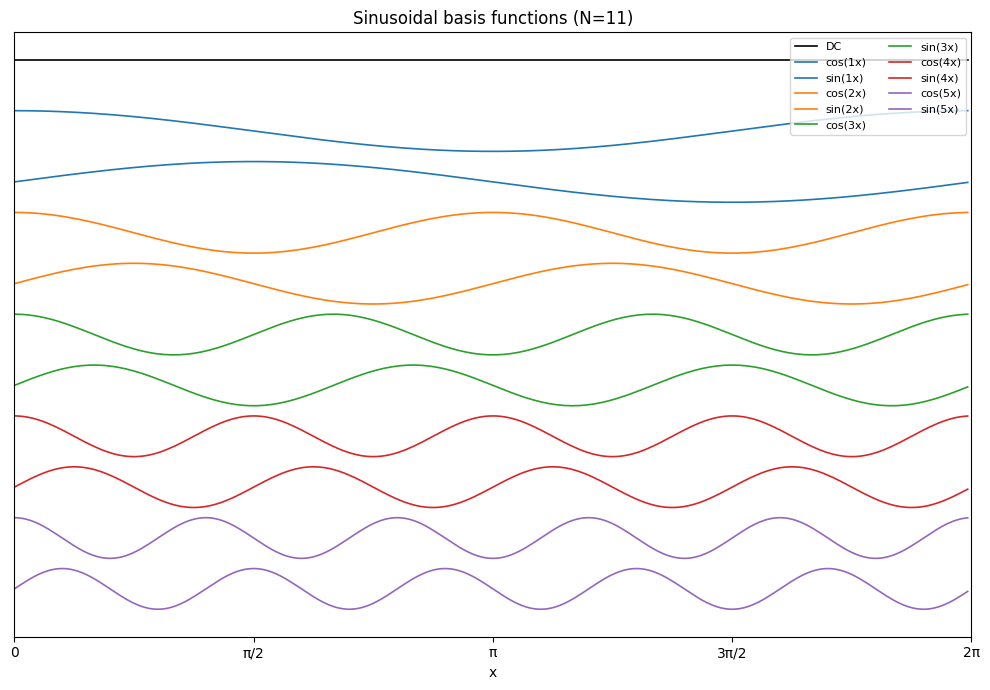

In [45]:
import matplotlib.pyplot as plt

# Plot each basis function as a separate trace, offset vertically so they
# don't overlap.  DC is shown in black; cos/sin pairs share a colour.
fig, ax = plt.subplots(figsize=(10, 7))

offset_step = 2.5  # vertical spacing between traces
cmap = plt.get_cmap("tab10")

for j in range(N):
    offset = (N - 1 - j) * offset_step  # top-to-bottom: DC at top

    if j == 0:
        label = "DC"
        color = "black"
    else:
        k = (j + 1) // 2  # frequency index
        label = f"cos({k}x)" if j % 2 == 1 else f"sin({k}x)"
        color = cmap((k - 1) % 10)

    ax.plot(x, B[:, j] + offset, color=color, lw=1.2, label=label)

ax.set_xlabel("x")
ax.set_xlim(0, 2 * np.pi)
ax.set_xticks([0, np.pi / 2, np.pi, 3 * np.pi / 2, 2 * np.pi])
ax.set_xticklabels(["0", "π/2", "π", "3π/2", "2π"])
ax.set_yticks([])
ax.set_title(f"Sinusoidal basis functions (N={N})")
ax.legend(loc="upper right", fontsize=8, ncol=2)

plt.tight_layout()
plt.show()

## 2. The Prior

Before seeing any data, we place a Gaussian prior on the weight vector $\mathbf{w}$:

$$w_j \sim \mathcal{N}(0,\, \sigma_j^2), \quad \text{independently}$$

The prior standard deviation decays exponentially with the sinusoidal order $k_j$:

$$\sigma_j = \gamma \, e^{-\varepsilon \, k_j}$$

- $\gamma$ controls the overall scale of the functions we expect to see.
- $\varepsilon$ controls how quickly high-frequency content is suppressed — larger $\varepsilon$ means smoother functions.

This encodes the reasonable belief that natural signals tend to have more energy at low frequencies than at high frequencies.

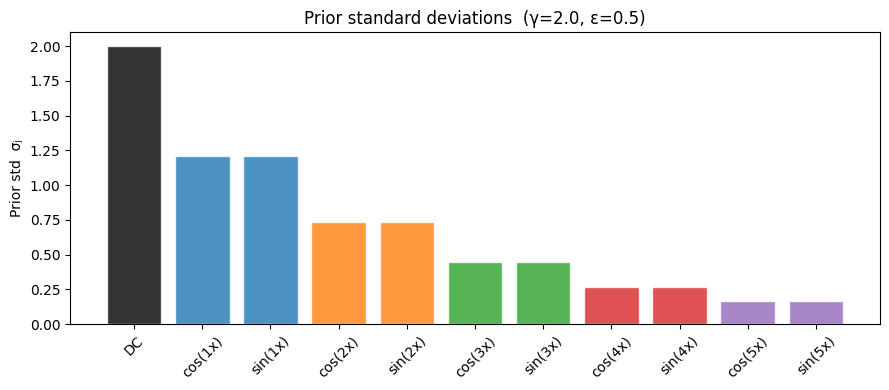

orders: [0 1 1 2 2 3 3 4 4 5 5]
sigma:  [2.    1.213 1.213 0.736 0.736 0.446 0.446 0.271 0.271 0.164 0.164]


In [46]:
# Prior on basis-function weights.
#
# Each weight w_j ~ N(0, sigma_j^2), where the standard deviation decays
# with the sinusoidal order k of that basis function:
#
#   sigma_j = gamma * exp(-epsilon * k_j)
#
# k_j is 0 for DC, and equals the frequency index k for both cos(kx) and sin(kx).
# With gamma=2 and epsilon=0.5 this gives sigma=2 for DC, ~1.2 at k=1, ~0.74 at k=2, …

gamma = 2.0  # base standard deviation
epsilon = 0.5  # exponential decay rate with sinusoidal order

# Sinusoidal order for each of the N basis functions:
#   j=0 (DC) -> k=0,  j=1,2 (cos/sin at k=1) -> k=1,  j=3,4 -> k=2, …
orders = (np.arange(N) + 1) // 2  # shape (N,)
sigma = gamma * np.exp(-epsilon * orders)  # prior std for each weight

# Build labels for the plot
labels = ["DC"] + [
    f"{'cos' if j % 2 == 1 else 'sin'}({(j + 1) // 2}x)" for j in range(1, N)
]

# Visualise the prior standard deviations
fig, ax = plt.subplots(figsize=(9, 4))
bar_colors = ["black"] + [cmap(((j + 1) // 2 - 1) % 10) for j in range(1, N)]
ax.bar(labels, sigma, color=bar_colors, alpha=0.8, edgecolor="white")
ax.set_ylabel("Prior std  σⱼ")
ax.set_title(f"Prior standard deviations  (γ={gamma}, ε={epsilon})")
ax.tick_params(axis="x", rotation=45)
plt.tight_layout()
plt.show()

print("orders:", orders)
print("sigma: ", np.round(sigma, 3))

## 3. Samples from the Prior

To build intuition, let's draw a few weight vectors from the prior and plot the resulting functions $f(x) = \mathbf{B}\mathbf{w}$.

Each sample is a plausible function *before* we have seen any measurements. Notice that they are smooth — the prior's exponential decay on $\sigma_j$ suppresses jagged high-frequency variation. Try increasing $\varepsilon$ to make them smoother, or decreasing it to allow more wiggles.

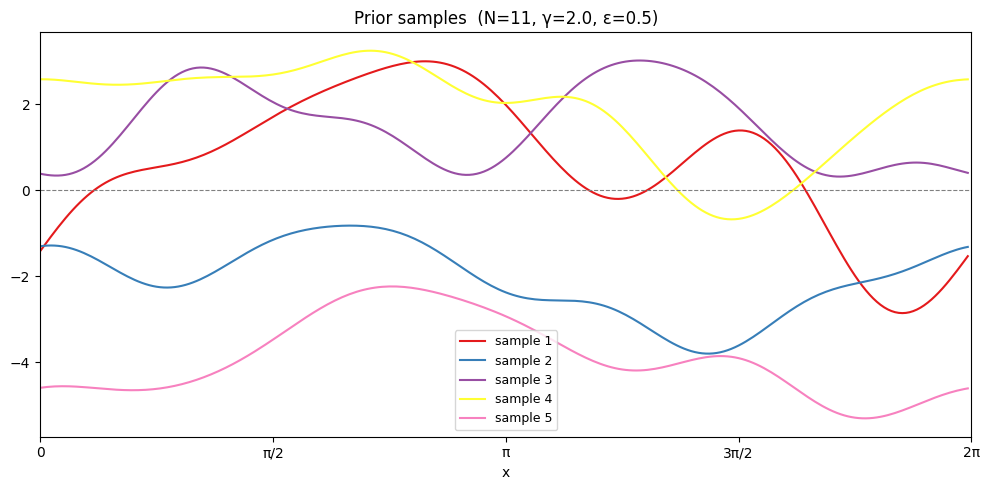

In [47]:
# Draw sample functions from the prior.
#
# A function is parameterised by a weight vector w of length N.
# The prior is w_j ~ N(0, sigma_j^2), independently for each j.
# The corresponding function is f(x) = B @ w  (shape M,).

rng = np.random.default_rng(seed=42)

n_samples = 5

# Draw weight vectors: each column is one sample, shape (N, n_samples)
W = rng.normal(loc=0.0, scale=sigma[:, np.newaxis], size=(N, n_samples))

# Evaluate the functions at all sample points, shape (M, n_samples)
F = B @ W

# Plot
fig, ax = plt.subplots(figsize=(10, 5))
sample_colors = plt.get_cmap("Set1")(np.linspace(0, 0.8, n_samples))

for s in range(n_samples):
    ax.plot(x, F[:, s], color=sample_colors[s], lw=1.5, label=f"sample {s + 1}")

ax.axhline(0, color="grey", lw=0.8, ls="--")
ax.set_xlabel("x")
ax.set_xlim(0, 2 * np.pi)
ax.set_xticks([0, np.pi / 2, np.pi, 3 * np.pi / 2, 2 * np.pi])
ax.set_xticklabels(["0", "π/2", "π", "3π/2", "2π"])
ax.set_title(f"Prior samples  (N={N}, γ={gamma}, ε={epsilon})")
ax.legend(fontsize=9)

plt.tight_layout()
plt.show()

## 4. Bayesian Inference

Now we observe noisy measurements and ask: *given the data, what is the most probable function?*

**The model:**
- True function: $f(x) = \mathbf{B}\mathbf{w}$, with $\mathbf{w}$ drawn from the prior above.
- Each measurement: $y_i = f(x_i) + \varepsilon_i$, where $\varepsilon_i \sim \mathcal{N}(0, \sigma_n^2)$ is independent noise.

**The posterior** — because both prior and likelihood are Gaussian, the posterior $p(\mathbf{w} \mid \mathbf{y})$ is also Gaussian. The update is exact and closed-form:

$$\boldsymbol{\Sigma}_\text{post} = \left(\boldsymbol{\Lambda}^{-1} + \frac{1}{\sigma_n^2}\boldsymbol{\Phi}^\top\boldsymbol{\Phi}\right)^{-1}, \qquad \boldsymbol{\mu}_\text{post} = \boldsymbol{\Sigma}_\text{post} \frac{\boldsymbol{\Phi}^\top \mathbf{y}}{\sigma_n^2}$$

where $\boldsymbol{\Lambda} = \mathrm{diag}(\sigma_j^2)$ is the prior covariance and $\boldsymbol{\Phi}$ is the **design matrix** — the basis matrix **B** evaluated at the measurement locations.

The posterior mean function $\hat{f}(x) = \mathbf{B}\,\boldsymbol{\mu}_\text{post}$ is our best estimate of the true function given the data.

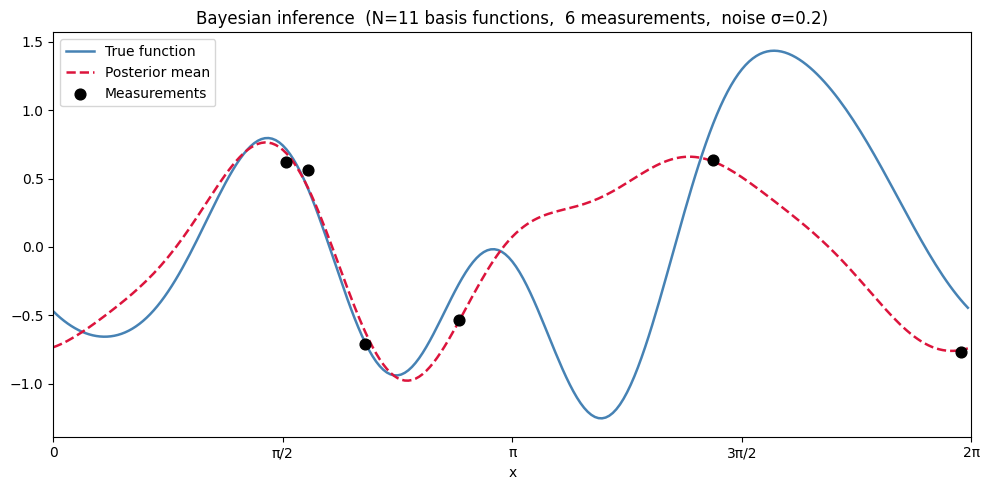

In [48]:
# ── Parameters ───────────────────────────────────────────────────────────────
noise_std = 0.2  # known measurement noise standard deviation
n_meas = 6  # number of measurements

rng_inf = np.random.default_rng(seed=7)

# ── 1. Draw a true function from the prior ───────────────────────────────────
w_true = rng_inf.normal(0.0, sigma)  # weight vector, shape (N,)
f_true = B @ w_true  # function values at all x, shape (M,)

# ── 2. Simulate noisy measurements ───────────────────────────────────────────
# Pick n_meas random locations on the domain, evaluate the true function there,
# then corrupt each value with independent Gaussian noise.
meas_idx = rng_inf.integers(0, M, size=n_meas)
x_meas = x[meas_idx]  # shape (n_meas,)
y_meas = f_true[meas_idx] + rng_inf.normal(0.0, noise_std, size=n_meas)

# ── 3. Build the design matrix Φ ─────────────────────────────────────────────
# Φ[i, j] = j-th basis function evaluated at measurement location x_meas[i].
# Shape (n_meas, N).  This is the "B matrix" restricted to the measurement points.
Phi = np.zeros((n_meas, N))
Phi[:, 0] = 1.0
for k in range(1, n_freqs + 1):
    Phi[:, 2 * k - 1] = np.cos(k * x_meas)
    Phi[:, 2 * k] = np.sin(k * x_meas)

# ── 4. Gaussian posterior over weights ───────────────────────────────────────
# Prior:      w   ~ N(0, Λ)          where Λ = diag(sigma²)
# Likelihood: y_i = Φ[i,:] @ w + ε,  ε ~ N(0, noise_std²)
#
# Standard Gaussian-Gaussian conjugate update gives:
#   Posterior covariance:  Σ = (Λ⁻¹  +  ΦᵀΦ / noise_std²)⁻¹
#   Posterior mean:        μ = Σ @ (Φᵀ y / noise_std²)

Lambda_inv = np.diag(1.0 / sigma**2)
Sigma_post = np.linalg.inv(Lambda_inv + Phi.T @ Phi / noise_std**2)
mu_post = Sigma_post @ (Phi.T @ y_meas / noise_std**2)

# Evaluate the posterior mean function over the full domain
f_post_mean = B @ mu_post  # shape (M,)

# ── 5. Plot ───────────────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(10, 5))

ax.plot(x, f_true, color="steelblue", lw=1.8, label="True function")
ax.plot(x, f_post_mean, color="crimson", lw=1.8, ls="--", label="Posterior mean")
ax.scatter(x_meas, y_meas, color="black", zorder=5, s=60, label="Measurements")

ax.set_xlabel("x")
ax.set_xlim(0, 2 * np.pi)
ax.set_xticks([0, np.pi / 2, np.pi, 3 * np.pi / 2, 2 * np.pi])
ax.set_xticklabels(["0", "π/2", "π", "3π/2", "2π"])
ax.set_title(
    f"Bayesian inference  "
    f"(N={N} basis functions,  {n_meas} measurements,  noise σ={noise_std})"
)
ax.legend()
plt.tight_layout()
plt.show()

## 5. More Data → Better Estimate

With only 6 measurements the posterior mean captures the rough shape but misses some detail. Below we repeat the inference on the **same true function** with 15 measurements to see how the estimate improves.

The key intuition: each new measurement adds a row to $\boldsymbol{\Phi}$, which increases the $\boldsymbol{\Phi}^\top\boldsymbol{\Phi}$ term and pulls the posterior mean closer to the data while shrinking the posterior covariance. In the limit of infinite noiseless data the posterior collapses to a point at the true weights.

In [ ]:
# Same true function (w_true / f_true from above), more measurements.
# A separate fixed-seed RNG controls measurement sampling so this cell is
# fully reproducible regardless of what ran before it.

n_meas_20 = 15
rng_20 = np.random.default_rng(seed=99)  # frozen seed → same draws every run

meas_idx_20 = rng_20.integers(0, M, size=n_meas_20)
x_meas_20 = x[meas_idx_20]
y_meas_20 = f_true[meas_idx_20] + rng_20.normal(0.0, noise_std, size=n_meas_20)

# Design matrix and posterior update (same formulas, more rows in Φ)
Phi_20 = np.zeros((n_meas_20, N))
Phi_20[:, 0] = 1.0
for k in range(1, n_freqs + 1):
    Phi_20[:, 2 * k - 1] = np.cos(k * x_meas_20)
    Phi_20[:, 2 * k] = np.sin(k * x_meas_20)

Sigma_post_20 = np.linalg.inv(Lambda_inv + Phi_20.T @ Phi_20 / noise_std**2)
mu_post_20 = Sigma_post_20 @ (Phi_20.T @ y_meas_20 / noise_std**2)
f_post_mean_20 = B @ mu_post_20

# Plot
fig, axes = plt.subplots(1, 2, figsize=(14, 5), sharey=True)

cases = [
    (n_meas, x_meas, y_meas, f_post_mean),
    (n_meas_20, x_meas_20, y_meas_20, f_post_mean_20),
]
for ax, (nm, xm, ym, fpm) in zip(axes, cases, strict=True):
    ax.plot(x, f_true, color="steelblue", lw=1.8, label="True function")
    ax.plot(x, fpm, color="crimson", lw=1.8, ls="--", label="Posterior mean")
    ax.scatter(xm, ym, color="black", zorder=5, s=50, label=f"{nm} measurements")
    ax.set_xlim(0, 2 * np.pi)
    ax.set_xticks([0, np.pi / 2, np.pi, 3 * np.pi / 2, 2 * np.pi])
    ax.set_xticklabels(["0", "π/2", "π", "3π/2", "2π"])
    ax.set_title(f"{nm} measurements  (noise σ={noise_std})")
    ax.legend(fontsize=8)

fig.suptitle(f"Homing in — N={N} basis functions", fontsize=13)
plt.tight_layout()
plt.show()

## 6. Posterior Uncertainty — Confidence Intervals

The posterior covariance $\boldsymbol{\Sigma}_\text{post}$ tells us not just *where* the estimate is, but *how uncertain* it is at every point on the domain.

The posterior predictive variance at a single point $x$ is:

$$\sigma^2_\text{post}(x) = \mathbf{b}(x)^\top \boldsymbol{\Sigma}_\text{post}\, \mathbf{b}(x)$$

where $\mathbf{b}(x)$ is the vector of basis functions evaluated at $x$ (one row of **B**).  Doing this for all $M$ sample points at once:

$$\text{diag}\!\left(\mathbf{B}\,\boldsymbol{\Sigma}_\text{post}\,\mathbf{B}^\top\right)$$

The square root gives the posterior standard deviation $\sigma_\text{post}(x)$, and the shaded band below is the 95 % credible interval $\hat{f}(x) \pm 1.96\,\sigma_\text{post}(x)$.

Notice how the band is narrowest near the measurement locations (where the data constrain the estimate) and widest in the gaps between them.  With more measurements the band shrinks everywhere.

In [ ]:
# Posterior predictive standard deviation at every sample point.
#
# Var[f(x)] = b(x)^T @ Sigma_post @ b(x) for a single point x.
# For all M points at once: diag(B @ Sigma_post @ B^T).
# We compute this efficiently without forming the full (M x M) matrix:
#   diag(B @ Sigma_post @ B^T)[i] = sum_j (B @ Sigma_post)[i,j] * B[i,j]


def posterior_std(Sig: np.ndarray) -> np.ndarray:
    """Return pointwise posterior std over the full domain given Sigma_post."""
    BSig = B @ Sig  # (M, N)
    var = np.sum(BSig * B, axis=1)  # (M,) — diag of B Sig B^T
    return np.sqrt(np.maximum(var, 0.0))  # guard against tiny negatives


std_6 = posterior_std(Sigma_post)
std_20 = posterior_std(Sigma_post_20)

z95 = 1.96  # multiplier for a 95 % credible interval

# ── Plot ──────────────────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5), sharey=True)

# Use a distinct variable name to avoid mypy confusing this with the earlier
# 4-element cases list defined in the homing-in cell.
ci_cases = [
    (n_meas, x_meas, y_meas, f_post_mean, std_6, "6 measurements"),
    (n_meas_20, x_meas_20, y_meas_20, f_post_mean_20, std_20, "15 measurements"),
]
for ax, (nm, xm, ym, fpm, std, title) in zip(axes, ci_cases, strict=True):
    # 95 % credible band
    ax.fill_between(
        x,
        fpm - z95 * std,
        fpm + z95 * std,
        color="crimson",
        alpha=0.15,
        label="95 % credible interval",
    )
    ax.plot(x, f_true, color="steelblue", lw=1.8, label="True function")
    ax.plot(x, fpm, color="crimson", lw=1.8, ls="--", label="Posterior mean")
    ax.scatter(xm, ym, color="black", zorder=5, s=50, label=f"{nm} measurements")
    ax.set_xlim(0, 2 * np.pi)
    ax.set_xticks([0, np.pi / 2, np.pi, 3 * np.pi / 2, 2 * np.pi])
    ax.set_xticklabels(["0", "π/2", "π", "3π/2", "2π"])
    ax.set_title(title)
    ax.legend(fontsize=8)

fig.suptitle(
    f"Posterior mean ± 1.96σ  (N={N} basis functions, noise σ={noise_std})",
    fontsize=13,
)
plt.tight_layout()
plt.show()

## 7. Adaptive Sampling

So far we placed measurements at **random** locations. But given the posterior, we can do better: place each new measurement where we are currently *most uncertain* — i.e., where the posterior credible interval is widest.

**The greedy algorithm:**
1. Start with the prior (no data).
2. Compute the posterior predictive std $\sigma_\text{post}(x)$ at every point.
3. Pick the next measurement location $x^* = \arg\max_x \,\sigma_\text{post}(x)$.
4. Observe $y^* = f(x^*) + \varepsilon$ and update the posterior.
5. Repeat.

Each new measurement is placed exactly where it will do the most good.  Watch how the credible band (shaded) collapses first in the regions that have been sampled, while the algorithm hunts down the remaining uncertain regions.

The sequential posterior update is implemented by maintaining the **information matrix** $\mathbf{A} = \boldsymbol{\Lambda}^{-1} + \boldsymbol{\Phi}^\top\boldsymbol{\Phi}/\sigma_n^2$ and **information vector** $\mathbf{c} = \boldsymbol{\Phi}^\top\mathbf{y}/\sigma_n^2$.  Adding one measurement $({\boldsymbol\phi}^*, y^*)$ is a cheap rank-1 update:

$$\mathbf{A} \;\leftarrow\; \mathbf{A} + \frac{{\boldsymbol\phi}^* {\boldsymbol\phi}^{*\top}}{\sigma_n^2}, \qquad \mathbf{c} \;\leftarrow\; \mathbf{c} + \frac{{\boldsymbol\phi}^* y^*}{\sigma_n^2}$$

then $\boldsymbol{\Sigma}_\text{post} = \mathbf{A}^{-1}$ and $\boldsymbol{\mu}_\text{post} = \mathbf{A}^{-1}\mathbf{c}$.

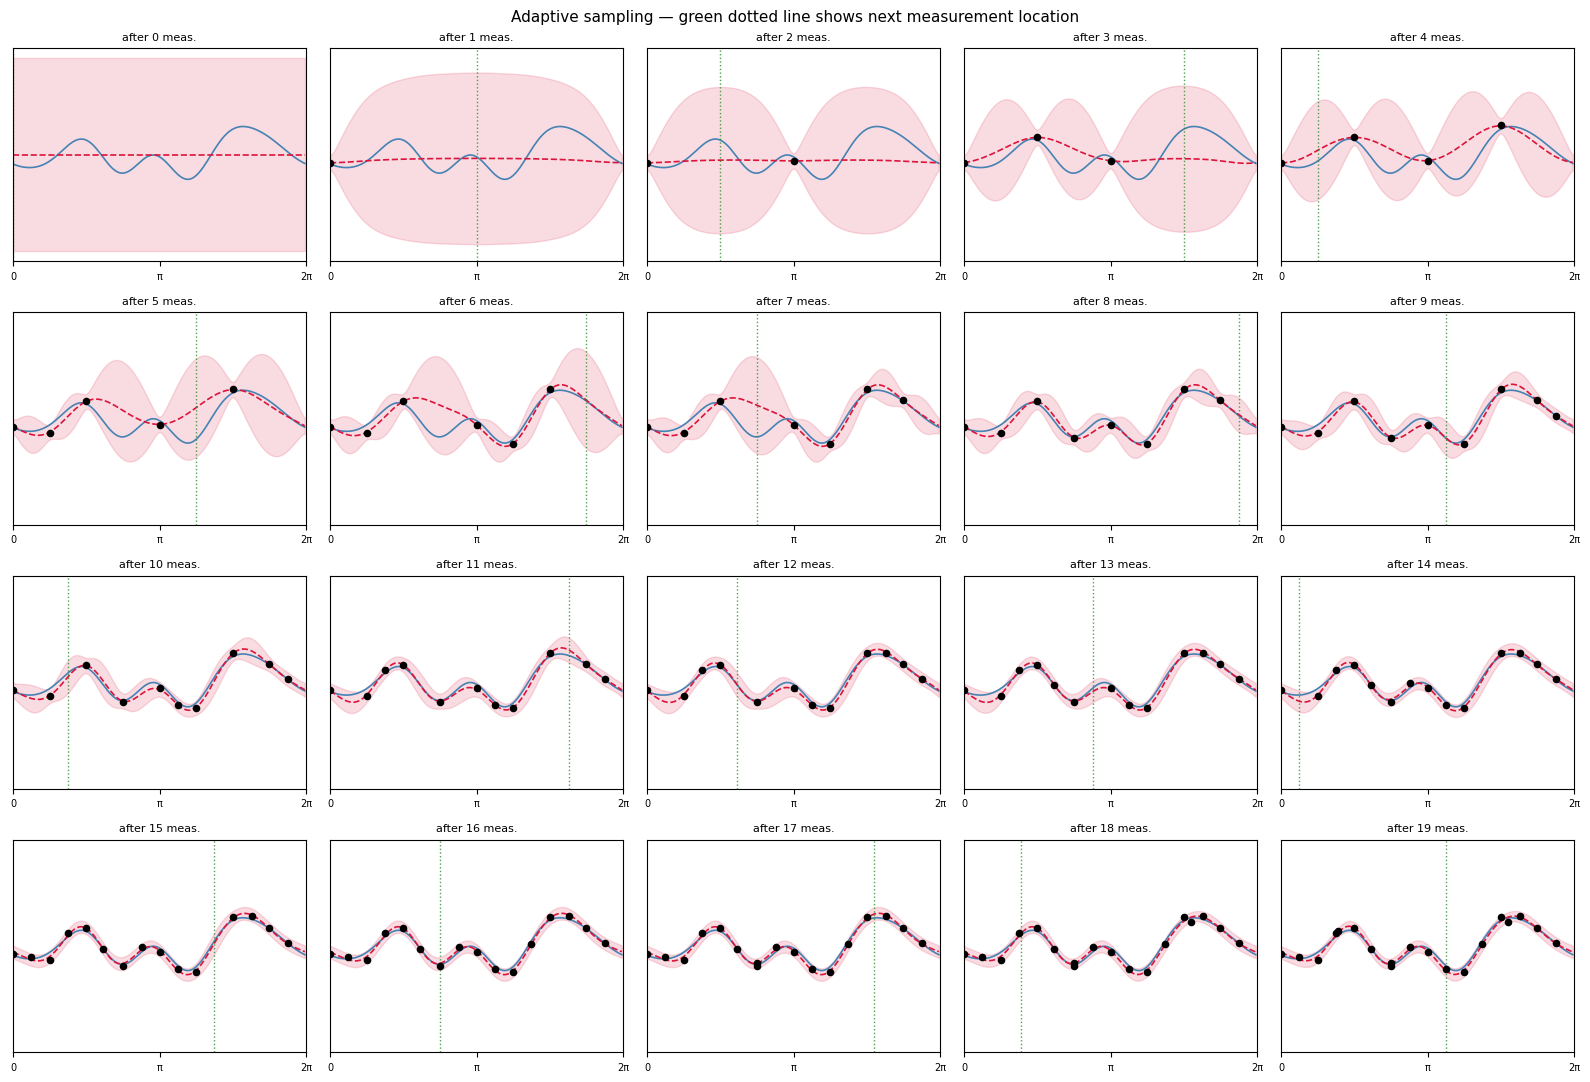

In [51]:
rng_adapt = np.random.default_rng(seed=42)
n_adaptive = 20

# ── Sequential posterior state ────────────────────────────────────────────────
# Maintain the information matrix A and vector c so each new measurement is
# a cheap rank-1 update rather than a full recomputation from scratch.
#
#   A  = Λ⁻¹  +  Φᵀ Φ / noise_std²      (N × N)
#   c  =          Φᵀ y / noise_std²      (N,)
#
# Then:  Σ_post = A⁻¹,   μ_post = A⁻¹ c

info_mat = Lambda_inv.copy()  # start from prior: A = Λ⁻¹, c = 0
info_vec = np.zeros(N)

x_meas_adapt: list[float] = []
y_meas_adapt: list[float] = []

# ── Montage setup ─────────────────────────────────────────────────────────────
n_cols = 5
n_rows = n_adaptive // n_cols
fig, axes = plt.subplots(n_rows, n_cols, figsize=(16, 11), sharey=True)
axes_flat = axes.flatten()

for step in range(n_adaptive):
    # Current posterior
    Sigma_adapt = np.linalg.inv(info_mat)
    mu_adapt = Sigma_adapt @ info_vec
    std_adapt = posterior_std(Sigma_adapt)
    f_mean_adapt = B @ mu_adapt

    # Choose next measurement: argmax of posterior std
    next_idx = int(np.argmax(std_adapt))
    x_next = x[next_idx]
    y_next = float(f_true[next_idx] + rng_adapt.normal(0.0, noise_std))

    # ── Plot this step ────────────────────────────────────────────────────────
    ax = axes_flat[step]
    ax.fill_between(
        x,
        f_mean_adapt - z95 * std_adapt,
        f_mean_adapt + z95 * std_adapt,
        color="crimson",
        alpha=0.15,
    )
    ax.plot(x, f_true, color="steelblue", lw=1.2)
    ax.plot(x, f_mean_adapt, color="crimson", lw=1.2, ls="--")
    if x_meas_adapt:
        ax.scatter(x_meas_adapt, y_meas_adapt, color="black", s=20, zorder=5)
    # Mark where the NEXT measurement will land
    ax.axvline(x_next, color="forestgreen", lw=1.0, ls=":", alpha=0.8)
    ax.set_xlim(0, 2 * np.pi)
    ax.set_xticks([0, np.pi, 2 * np.pi])
    ax.set_xticklabels(["0", "π", "2π"], fontsize=7)
    ax.set_yticks([])
    ax.set_title(f"after {step} meas.", fontsize=8)

    # ── Rank-1 posterior update ───────────────────────────────────────────────
    phi = B[next_idx, :]
    info_mat += np.outer(phi, phi) / noise_std**2
    info_vec += phi * y_next / noise_std**2

    x_meas_adapt.append(x_next)
    y_meas_adapt.append(y_next)

fig.suptitle(
    "Adaptive sampling — green dotted line shows next measurement location",
    fontsize=11,
)
plt.tight_layout()
plt.show()

## 8. Adaptive vs. Random Sampling — and the Connection to the WPPM Paper

The plot above shows how rapidly adaptively chosen measurements recover the true function.  Below we compare 20 adaptively sampled trials to 20 randomly placed ones, which highlights the difference.

TThe greedy maximum-variance strategy is a **Bayesian experimental design** approach to active learning. The same general idea underlies trial placement used for data collection in [Hong et al. (2025)](https://elifesciences.org/reviewed-preprints/108943v1).** Characterising human color discrimination requires estimating a smoothly-varying field of perceptual thresholds across a two-dimensional color space — a much harder problem than our 1-D toy example, but the same principle applies. The authors used **AEPsych**, a Gaussian-process-based adaptive sampling framework, to select each stimulus location sequentially based on where the current model was uncertain. This allowed characterization of discrimination thresholds across the full isoluminant plane using only ~6,000 trials per participant — a fraction of what a fixed grid design would have required.

The smoothness prior plays the same role in both settings: it regularises the estimate so that measurements at one location also inform neighbouring locations.  Smoothness also underlies the adaptive sampling approach.

In [ ]:
# Head-to-head comparison: 15 random measurements vs. 20 adaptive measurements.
# Both use the same true function and the same noise level.
# The adaptive posterior (right) was computed incrementally in the cell above.

Sigma_adapt_final = np.linalg.inv(info_mat)
mu_adapt_final = Sigma_adapt_final @ info_vec
f_adapt_final = B @ mu_adapt_final
std_adapt_final = posterior_std(Sigma_adapt_final)

fig, axes = plt.subplots(1, 2, figsize=(14, 5), sharey=True)

panel_cases = [
    (
        "15 random measurements",
        x_meas_20,
        y_meas_20,
        f_post_mean_20,
        std_20,
        "steelblue",
    ),
    (
        "20 adaptive measurements",
        np.array(x_meas_adapt),
        np.array(y_meas_adapt),
        f_adapt_final,
        std_adapt_final,
        "forestgreen",
    ),
]

for ax, (title, xm, ym, fpm, std, color) in zip(axes, panel_cases, strict=True):
    ax.fill_between(
        x,
        fpm - z95 * std,
        fpm + z95 * std,
        color=color,
        alpha=0.15,
        label="95 % credible interval",
    )
    ax.plot(x, f_true, color="steelblue", lw=1.8, label="True function")
    ax.plot(x, fpm, color=color, lw=1.8, ls="--", label="Posterior mean")
    ax.scatter(xm, ym, color="black", zorder=5, s=50, label=f"{len(xm)} measurements")
    ax.set_xlim(0, 2 * np.pi)
    ax.set_xticks([0, np.pi / 2, np.pi, 3 * np.pi / 2, 2 * np.pi])
    ax.set_xticklabels(["0", "π/2", "π", "3π/2", "2π"])
    ax.set_title(title, fontsize=12)
    ax.legend(fontsize=8)

# Quantify the improvement
rmse_random = float(np.sqrt(np.mean((f_post_mean_20 - f_true) ** 2)))
rmse_adaptive = float(np.sqrt(np.mean((f_adapt_final - f_true) ** 2)))
fig.suptitle(
    f"Random RMSE: {rmse_random:.3f}    Adaptive RMSE: {rmse_adaptive:.3f}   "
    f"({100 * (1 - rmse_adaptive / rmse_random):.0f} % reduction)",
    fontsize=12,
)
plt.tight_layout()
plt.show()